In [1]:
import numpy as np
import random
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = "clinical_trial_simulation.db"
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

cursor.execute('''
    CREATE TABLE IF NOT EXISTS trial_runs (
        run_id INTEGER PRIMARY KEY,
        run_type TEXT,
        target_efficacy REAL,
        is_approved BOOLEAN,
        timeline_months INTEGER,
        efficacy_rate REAL,
        npv REAL
    )
''')
cursor.execute('DELETE FROM trial_runs') #Reset the database for the next run

In [2]:
#Clinical Trial Phases pipeline
class ClinicalPipeline:
    """Simulating the phase progression of a clinical trial, tracking monthly patient enrollment,
    drug response in the cohort, and including unpredictable regulatory events."""
    def __init__(self, target_n, monthly_burn, expected_efficacy, approval_threshold, p1_prob, p2_prob):
        self.target_n = target_n
        self.expected_efficacy = expected_efficacy
        self.approval_threshold = approval_threshold

        """Phases 1 and 2 often have more predictable cost and duration because they require smaller numbers of patients enrolled,
        so they are less susceptible to big variations"""
        self.phase_1 = {"cost":5_000_000, "months":6, "prob":p1_prob}
        self.phase_2 = {"cost":20_000_000,  "months":18, "prob":p2_prob}

        #Phase 3
        """requires a big cohort (1000 patients in our simulation), so this phase is going to cause the biggest variations
        in terms of cost and time-to-market (it's esentially the bottleneck of clinical research)"""
        self.trial_active = True
        self.enrollment_rate = 30
        self.monthly_burn = monthly_burn

    def evaluate_regulatory_events(self, current_cost, current_months):
        """Introducing random real-world regulatory interventions from the FDA like safety signals or fast-track approvals into the timeline."""
        risk_roll = random.random()

        if risk_roll <= 0.01:
            self.trial_active = False #Severe Safety Signal (trial is terminated due to safety concerns)
        elif risk_roll <= 0.03:
             self.enrollment_rate *= 2 #Trial accelerated via FDA Fast Track (when a drug is intended to treat very serious conditions / unmet medical needs)
        elif risk_roll <= 0.05:
            current_months += 6 #Regulatory delay adds 6 months of costs without any patient progress
            current_cost += (self.monthly_burn * 6)
        return current_cost, current_months

    def run_pipeline(self):
        """The actual pipeline that goes through each phase of a clinical trial"""
        total_cost = 0
        total_months = 0

        #Phase 1: Safety
        total_cost += self.phase_1["cost"]
        total_months += self.phase_1["months"]
        if random.random() > self.phase_1["prob"]:
            return False, total_cost, total_months, 0

        #Phase 2: Efficacy
        total_cost += self.phase_2["cost"]
        total_months += self.phase_2["months"]
        if random.random() > self.phase_2["prob"]:
            return False, total_cost, total_months, 0

        #Phase 3: comparing the candidate drug to the current standard of care
        enrolled_patients = 0
        responders = 0

        while enrolled_patients < self.target_n and self.trial_active:
            total_months += 1
            total_cost += self.monthly_burn

            total_cost, total_months = self.evaluate_regulatory_events(total_cost, total_months)

            if self.trial_active:
                #Variations in monthly enrollment modeled using a Poisson distribution
                monthly_cohort = min(np.random.poisson(self.enrollment_rate), self.target_n - enrolled_patients)
                enrolled_patients += monthly_cohort

                #Cohort response (how many patients out of the 1000 enrolled actually responded to the new drug) calculated using a vectorized binomial distribution
                responders += np.random.binomial(n=monthly_cohort, p=self.expected_efficacy)

        is_approved = self.trial_active and (responders >= self.approval_threshold)
        return is_approved, total_cost, total_months, responders

In [3]:
#Financial Modeling
"""Calculating the Net Present Value (NPV) using a Lognormal distribution for modeling variations in market peak sales, while also taking into account
    the drug's clinical performance compared to a baseline expectation,and the R&D cost."""
def calculate_risk_adjusted_npv(is_approved, r_and_d_cost, timeline_months, responders, target_n, baseline_soc):

    if not is_approved:
        return -r_and_d_cost #R&D write-off

    #Adjusting the market baseline based on the drug's performance in comparison with the SoC
    actual_efficacy = responders / target_n
    adjusted_market_base = 500_000_000 * (actual_efficacy / baseline_soc)

    #Market Volatility (used a Lognormal roll for modeling peak sales, capturing the potential of 'blockbuster' drugs to generate huge revenues)
    market_volatility = 0.8
    peak_sales = np.random.lognormal(mean=np.log(adjusted_market_base), sigma=market_volatility)

    #Net Present Value (Discounting delayed revenue)
    discount_rate = 0.10
    years_to_market = timeline_months / 12
    discounted_revenue = peak_sales / ((1 + discount_rate) ** years_to_market)

    return discounted_revenue - r_and_d_cost

In [4]:
#Monte Carlo Simulations using Dynamic FDA Thresholds for different drug categories
DRUG_PROFILES = {
    "1": {"name": "Oncology", "soc": 0.30, "margin": 0.05, "burn_rate": 3_000_000, "p1_prob": 0.55, "p2_prob": 0.25, "min_pos": 5.0, "translation": 0.70},
    "2": {"name": "Immunology", "soc": 0.50, "margin": 0.05, "burn_rate": 1_500_000, "p1_prob": 0.65, "p2_prob": 0.45, "min_pos": 10.0, "translation": 0.80},
    "3": {"name": "Rare Diseases", "soc": 0.15, "margin": 0.10, "burn_rate": 1_000_000, "p1_prob": 0.60, "p2_prob": 0.55, "min_pos": 15.0, "translation": 0.90}
}

print("Available Therapeutic areas:")
print("1. Oncology")
print("2. Immunology")
print("3. Rare Diseases")

category_id = input("Select your candidate's therapeutic area (1/2/3): ")
profile = DRUG_PROFILES.get(category_id, DRUG_PROFILES["1"])

"""Added margins to the SoC because a new drug has to have a statistically meaningful superior effect compared to the current SoC.
Rare diseases need to have a bigger margin because they usually have smaller cohorts (harder to find patients to enroll) resulting in lower statistical power."""
fda_target_rate = profile["soc"] + profile["margin"]
target_threshold = int(1000 * fda_target_rate)

print(f"\nSelected: {profile['name']}. FDA Approval Threshold is {fda_target_rate*100:.0f}%.")

user_input = input("\nEnter your preclinical efficacy (e.g. 0.40 for 40%): ")
user_preclinical_eff = float(user_input)
user_clinical_eff = user_preclinical_eff * profile["translation"]

#Efficacy sweeping - running simulations for multiple arbitrary efficacies and calculating their corresponding mean NPVs, creating a baseline that we can compare our candidate to
SWEEP_RUNS = 1000
sweep_efficacies = np.linspace(profile["soc"] - 0.10, fda_target_rate + 0.10, num=10)
for test_eff in sweep_efficacies:
    for _ in range(SWEEP_RUNS):
        trial = ClinicalPipeline(target_n=1000, expected_efficacy=test_eff, approval_threshold=target_threshold, monthly_burn=profile["burn_rate"], p1_prob=profile["p1_prob"], p2_prob=profile["p2_prob"])
        approved, cost, months, successes = trial.run_pipeline()
        npv = calculate_risk_adjusted_npv(approved, cost, months, successes, 1000, fda_target_rate)

        cursor.execute('INSERT INTO trial_runs (run_type, target_efficacy, is_approved, timeline_months, efficacy_rate, npv) VALUES (?, ?, ?, ?, ?, ?)',
                       ('sweep', test_eff, approved, months, successes/1000, npv))

#Simulating the user's candidate
USER_RUNS = 2000
for _ in range(USER_RUNS):
    trial = ClinicalPipeline(target_n=1000, expected_efficacy=user_clinical_eff, approval_threshold=target_threshold, monthly_burn=profile["burn_rate"], p1_prob=profile["p1_prob"], p2_prob=profile["p2_prob"])
    approved, cost, months, successes = trial.run_pipeline()
    npv = calculate_risk_adjusted_npv(approved, cost, months, successes, 1000, fda_target_rate)

    cursor.execute('INSERT INTO trial_runs (run_type, target_efficacy, is_approved, timeline_months, efficacy_rate, npv) VALUES (?, ?, ?, ?, ?, ?)',
                   ('user', user_clinical_eff, approved, months, successes/1000, npv))

conn.commit()

Available Therapeutic areas:
1. Oncology
2. Immunology
3. Rare Diseases
Select your candidate's therapeutic area (1/2/3): 1

Selected: Oncology. FDA Approval Threshold is 35%.

Enter your preclinical efficacy (e.g. 0.40 for 40%): 0.60


In [5]:
#Analytics
df = pd.read_sql_query("SELECT * FROM trial_runs", conn)
user_df = df[df['run_type'] == 'user']
sweep_df = df[df['run_type'] == 'sweep']

print("\nRaw data preview (candidate's first 10 simulations)")
pd.set_option('display.expand_frame_repr', False)
print(user_df.head(10))

user_approvals = user_df[user_df['is_approved'] == True]
user_failures = user_df[user_df['is_approved'] == False]
num_approved = len(user_approvals)
num_failed = len(user_failures)
user_success_rate = (num_approved / USER_RUNS) * 100
user_avg_npv = user_df['npv'].mean()
p12_survival_rate = (profile["p1_prob"] * profile["p2_prob"]) * 100


print("\nUser's candidate assessment")
print(f"User's Preclinical Efficacy: {user_preclinical_eff * 100:.1f}%")
print(f"Estimated Clinical Efficacy: {user_clinical_eff * 100:.1f}%, adjusted using a 'clinical translation' factor of {profile['translation']:.2f}")

print(f"\nProjected Phase 1 & 2 Survival: {p12_survival_rate:.1f}%")
print(f"Projected End-to-End Clinical Success Rate: {user_success_rate:.2f}%")
print(f"Expected NPV: ${user_avg_npv:,.2f}")

print(f"\nUser's total approvals: {num_approved}")
print(f"User's total failures: {num_failed}")

if num_approved > 0:
    avg_npv_approved = user_approvals['npv'].mean()
    avg_time_approved = user_approvals['timeline_months'].mean()
    best_run = user_approvals.loc[user_approvals['npv'].idxmax()]
    print(f"\nAverage NPV (Approved): ${avg_npv_approved/1e6:,.1f}M")
    print(f"Average Time to Market (Approved): {avg_time_approved:.0f} months")
    print(f"\nBest run = blockbuster drug:")
    print(f"Maximum NPV: ${best_run['npv']:,.2f}")
    print(f"Timeline to Market: {best_run['timeline_months']:.0f} months")
    print(f"Efficacy Rate: {best_run['efficacy_rate']*100:.1f}%")

if num_failed > 0:
    avg_npv_failed = user_failures['npv'].mean()
    # Calculating Failure by Phase based on timeline milestones
    p1_fails = len(user_failures[user_failures['timeline_months'] == 6])
    p2_fails = len(user_failures[user_failures['timeline_months'] == 24])
    p3_fails = len(user_failures[user_failures['timeline_months'] > 24])

    print(f"\nAverage NPV (Failed): -${abs(avg_npv_failed)/1e6:,.1f}M")
    print(f"Failure by phase: \n{p1_fails} failed Phase 1 \n{p2_fails} failed Phase 2 \n{p3_fails} failed Phase 3")


viability_curve = sweep_df.groupby('target_efficacy')['npv'].mean()
print("\nEfficacy sweep viability curve")
for efficacy, avg_npv in viability_curve.items():
    status = "profitable" if avg_npv > 0 else "not profitable"
    print(f"For {efficacy*100:.0f}% efficacy the average NPV is ${avg_npv:,.2f} ({status})")

print("\n")

"""Analyzing our candidate's clinical trial viability by benchmarking its simulated performance
against the minimum acceptable success rate (Phase 1 to Market) for its specific drug category."""
acceptable_pos = profile["min_pos"]

if user_avg_npv > 0 and user_success_rate >= acceptable_pos:
    print(f"🟢 Go. Expected NPV is positive (${user_avg_npv/1e6:,.1f}M) with a robust Probability of Success ({user_success_rate:.1f}%). Proceed to clinical trials.")
elif user_avg_npv > 0 and user_success_rate < acceptable_pos:
    print(f"🟡 Risky-Go. The Probability of Success ({user_success_rate:.1f}%) is below the acceptable threshold. Proceed to clinical trials with caution.")
else:
    print("🔴 No-Go. Proceeding to clinical trials is not recommended.")
print("\n\n")


Raw data preview (candidate's first 10 simulations)
       run_id run_type  target_efficacy  is_approved  timeline_months  efficacy_rate           npv
10000   10001     user             0.42            0                6          0.000 -5.000000e+06
10001   10002     user             0.42            1               66          0.416  3.479387e+08
10002   10003     user             0.42            0                6          0.000 -5.000000e+06
10003   10004     user             0.42            1               48          0.428  4.341640e+08
10004   10005     user             0.42            1               45          0.428  4.119252e+08
10005   10006     user             0.42            0               24          0.000 -2.500000e+07
10006   10007     user             0.42            0               24          0.000 -2.500000e+07
10007   10008     user             0.42            1               50          0.446  1.136064e+09
10008   10009     user             0.42            0    

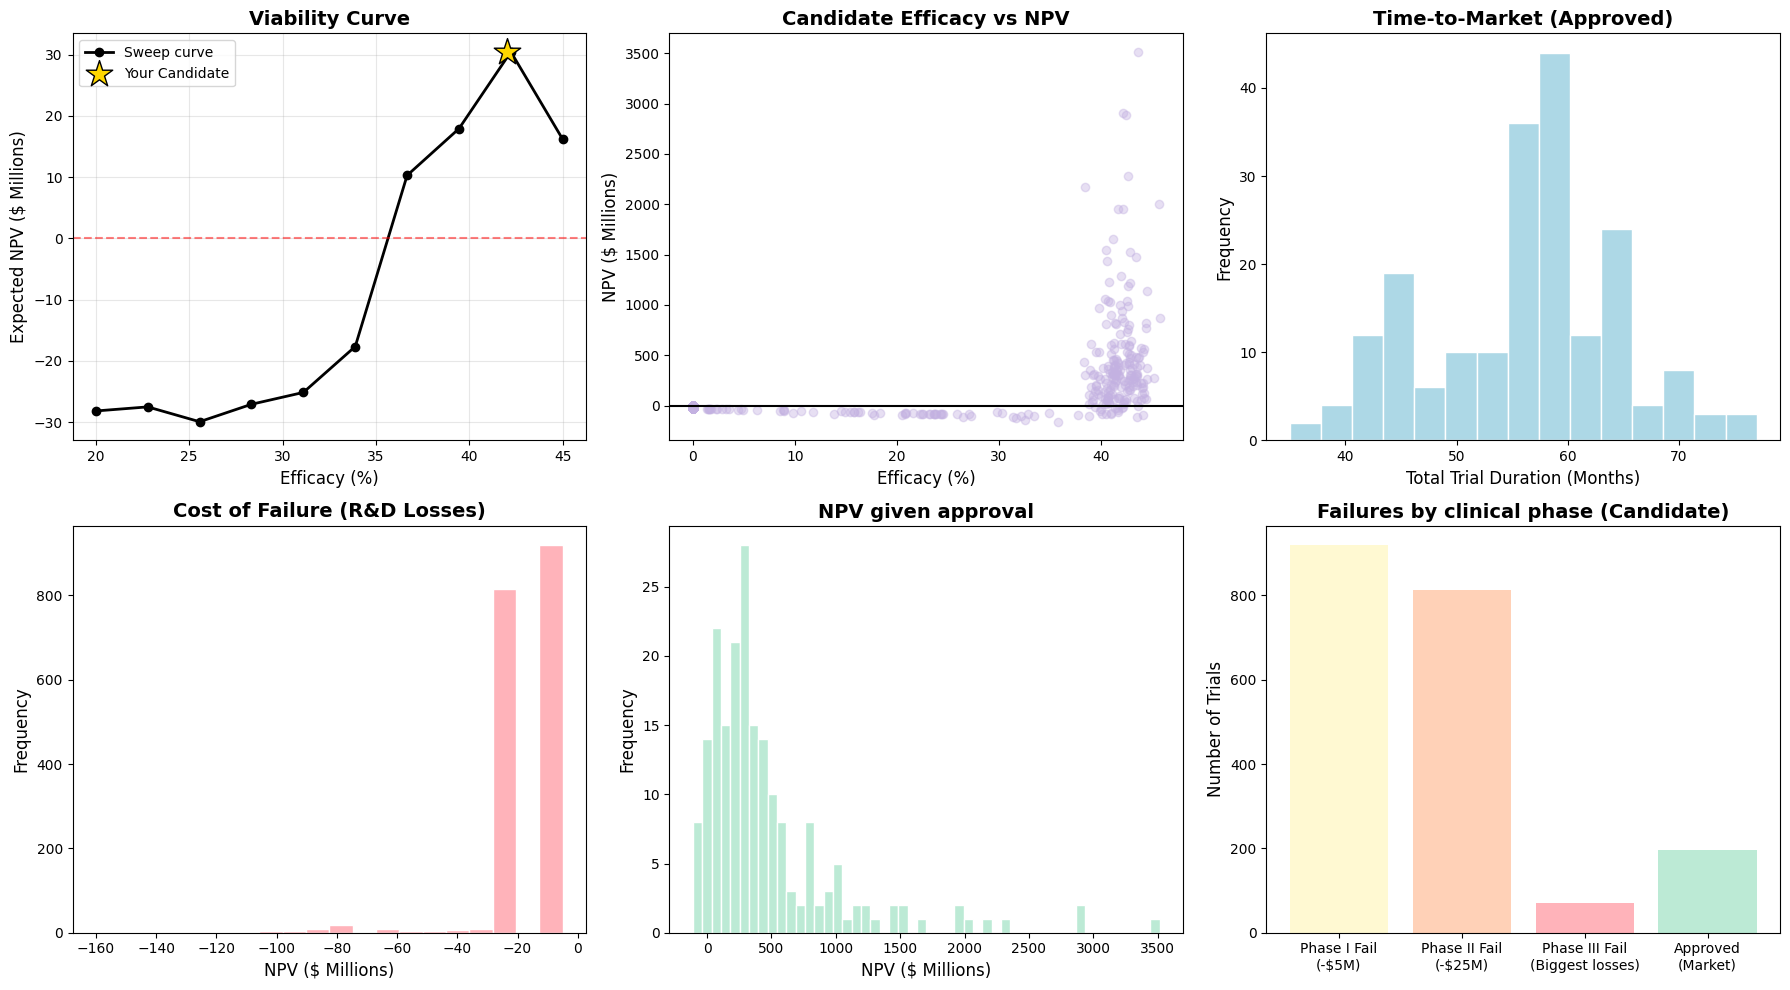

In [6]:
#Visualization
plt.figure(figsize=(18, 10))

#1. The Viability Curve (Candidate's clinical efficacy vs sweep)
plt.subplot(2, 3, 1)
sweep_curve = sweep_df.groupby('target_efficacy')['npv'].mean().reset_index()
user_eff = user_df['target_efficacy'].iloc[0]

plt.plot(sweep_curve['target_efficacy'] * 100, sweep_curve['npv'] / 1e6,
         marker='o', linestyle='-', color='black', linewidth=2, label="Sweep curve")
plt.scatter([user_eff * 100], [user_avg_npv / 1e6],
            color='gold', edgecolors='black', s=400, marker='*', zorder=5, label="Your Candidate")
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title("Viability Curve", fontsize=14, fontweight='bold')
plt.xlabel("Efficacy (%)", fontsize=12)
plt.ylabel("Expected NPV ($ Millions)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

#2. Efficacy vs NPV
plt.subplot(2, 3, 2)
plt.scatter(user_df['efficacy_rate'] * 100, user_df['npv'] / 1e6, alpha=0.4, color='#C3B1E1')
plt.axhline(0, color='black', linestyle='-')
plt.title("Candidate Efficacy vs NPV", fontsize=14, fontweight='bold')
plt.xlabel("Efficacy (%)", fontsize=12)
plt.ylabel("NPV ($ Millions)", fontsize=12)

#3. Time-to-Market
plt.subplot(2, 3, 3)
plt.hist(user_approvals['timeline_months'], bins=15, color='lightblue', edgecolor='white')
plt.title("Time-to-Market (Approved)", fontsize=14, fontweight='bold')
plt.xlabel("Total Trial Duration (Months)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

#4. R&D Losses Given Failure
plt.subplot(2, 3, 4)
plt.hist(user_failures['npv'] / 1e6, bins=20, color='#ffb3ba', edgecolor='white')
plt.title("Cost of Failure (R&D Losses)", fontsize=14, fontweight='bold')
plt.xlabel("NPV ($ Millions)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

#5. NPV Given Approval
plt.subplot(2, 3, 5)
plt.hist(user_approvals['npv'] / 1e6, bins=50, color='#BCEAD5', edgecolor='white')
plt.title("NPV given approval", fontsize=14, fontweight='bold')
plt.xlabel("NPV ($ Millions)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

#6. Clinical phase failures
plt.subplot(2, 3, 6)

stages = ['Phase I Fail\n(-$5M)', 'Phase II Fail\n(-$25M)', 'Phase III Fail\n(Biggest losses)', 'Approved\n(Market)']
counts = [p1_fails, p2_fails, p3_fails, num_approved]
colors = ['#FFF9D2', '#FFD1B7', '#ffb3ba', '#BCEAD5']

plt.bar(stages, counts, color=colors)
plt.title("Failures by clinical phase (Candidate)", fontsize=14, fontweight='bold')
plt.ylabel("Number of Trials", fontsize=12)

plt.tight_layout()
plt.show()